In [2]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


# Read the Data

In [3]:
import pandas as pd

df = pd.read_csv("Airline.csv")
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [4]:
#


# Handle the Null Values

In [5]:
df.isnull().sum()


ID                 0
Airline            0
Date_of_Journey    0
Source             2
Destination        2
Route              3
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              3
dtype: int64

In [6]:
# Handle Null Values from Price
# Drop or replace the null with mean/median

df[df['Price'].isnull()]
mean_Price = df["Price"].mean()
mean_Price
df.fillna({'Price':mean_Price},inplace=True)



,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,3,Jet Airways,09-06-2019,Delhi,Cochin,DEL _ LKO _ BOM _ COK,09:25,10-06-2026 04:25,19h,2 stops,No info,13882.0
3,4,IndiGo,12-05-2019,Kolkata,Banglore,CCU _ NAG _ BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,5,IndiGo,01-03-2019,Banglore,New Delhi,BLR _ NAG _ DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10684,10679,Air Asia,09-04-2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107.0
10685,10680,Air India,27-04-2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145.0
10686,10681,Jet Airways,27-04-2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229.0
10687,10682,Vistara,01-03-2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648.0


In [7]:
# Handle Missing Values of Source,Destinatoin and Stops 
# using mode(Most Frequent)
# Why are we using Mode? this is categoral columns
mode_Source = df['Source'].mode()[0]
mode_Source

df.fillna({'Source':mode_Source},inplace=True)

df[df['Source'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [8]:
mode_Desti = df['Destination'].mode()[0]

df.fillna({'Destination':mode_Desti},inplace=True)
df[df['Destination'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [9]:
df[df['Total_Stops'].isnull()]

mode_T_Stops =df['Total_Stops'].mode()[0]

df.fillna({'Total_Stops':mode_T_Stops},inplace=True)

df[df['Total_Stops'].isnull()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


# Remove the Duplicates

In [10]:
# Find and remove the Duplicates

df[df.duplicated()]

df.drop_duplicates(inplace=True)


In [11]:
df[df.duplicated()]


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [12]:
df.columns

for i in df.columns:
    print(i)


ID
Airline
Date_of_Journey
Source
Destination
Route
Dep_Time
Arrival_Time
Duration
Total_Stops
Additional_Info
Price


# Handle the Uneven Values

In [13]:
['Airline','Source','Destination','Total_Stops']


['Airline', 'Source', 'Destination', 'Total_Stops']

In [14]:
df['Airline'].unique()
df['Source'].unique()
df['Destination'].unique()
#df['Total_Stops'].unique()


<ArrowStringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [15]:
df['Airline'].value_counts()
df['Airline'] = df['Airline'].replace({'Multiple carriers Premium economy':'Multiple carriers'})
df['Airline'] = df['Airline'].replace({'Jet Airways Business':'Jet Airways'})
df['Airline'] = df['Airline'].replace({'Vistara Premium economy':'Vistara'})


df['Airline'].value_counts()


Airline
Jet Airways          3855
IndiGo               2053
Air India            1752
Multiple carriers    1209
SpiceJet              818
Vistara               482
Air Asia              319
GoAir                 194
Trujet                  1
Name: count, dtype: int64

In [16]:
df["Destination"] = df["Destination"].str.replace({'New Delhi':'Delhi'})


In [17]:
df['Destination'].unique()


<ArrowStringArray>
['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad']
Length: 5, dtype: str

In [18]:
df.head(2)


,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [19]:
# 


# Stat Based Analysis

In [20]:
df.describe()


,ID,Price
count,10683.000000,10683.000000
mean,5342.000000,9087.219176
std,3084.060797,4611.065933
min,1.000000,1759.000000
25%,2671.500000,5277.000000
50%,5342.000000,8372.000000
75%,8012.500000,12373.000000
max,10683.000000,79512.000000


# Graph Based Analysis

In [21]:
# install the liabraries

# pip install matplotlib
# pip install seaborn


In [22]:
# Import required Liabraries for Visualization

import matplotlib.pyplot as plt
import seaborn as sns


In [166]:
df.groupby('Airline')['Airline'].count().sort_values(ascending=False)


Airline
Jet Airways          3855
IndiGo               2053
Air India            1752
Multiple carriers    1209
SpiceJet              818
Vistara               482
Air Asia              319
GoAir                 194
Trujet                  1
Name: Airline, dtype: int64

In [158]:
i_a = df.groupby('Airline')['Airline'].count().sort_values(ascending=False).index


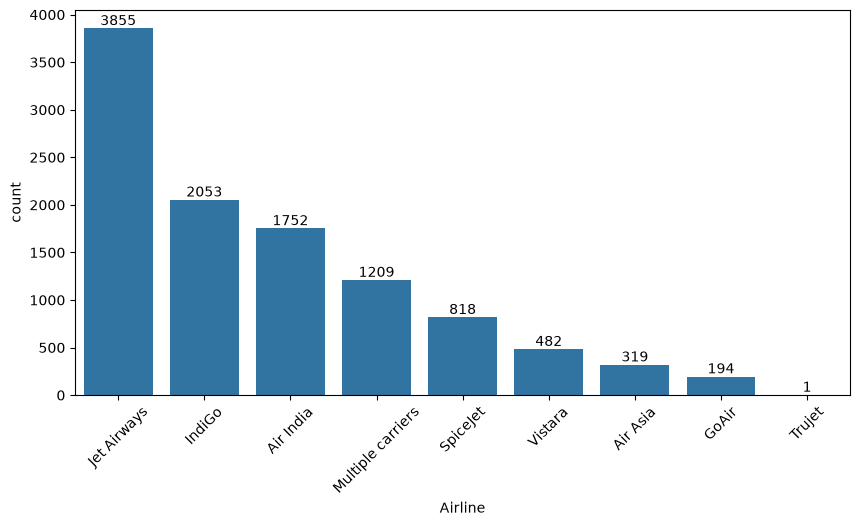

In [159]:
# Count Distribution against Each Airline

plt.figure(figsize=(10,5))
ax = sns.countplot(x=df['Airline'],order=i_a)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.show()


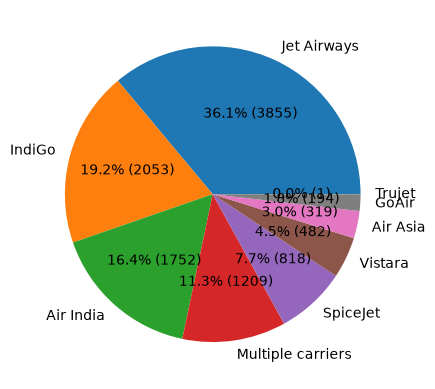

In [167]:
# Market share by count Pie Chart

Air_df = df.groupby('Airline')['Airline'].count().sort_values(ascending=False)

def label(df):
    def percentage(p):
        per = f'{p:.1f}%'
        value = f'{p * sum(df)/100:.0f}'
        return f'{per} ({value})'
    return percentage


plt.pie(Air_df,labels=Air_df.index,autopct=label(Air_df))
plt.show()


In [171]:
S_i = df.groupby('Source')['Source'].count().sort_values(ascending=False).index


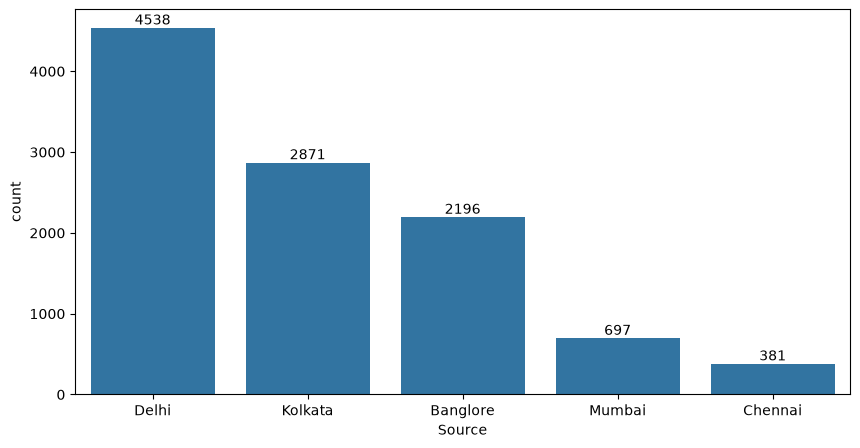

In [172]:
# Count Distribution against Each Source
# Need to know how many flight are flying from each city(Source)

plt.figure(figsize=(10,5))
ax = sns.countplot(x=df['Source'],order=S_i)
ax.bar_label(ax.containers[0])
plt.show()


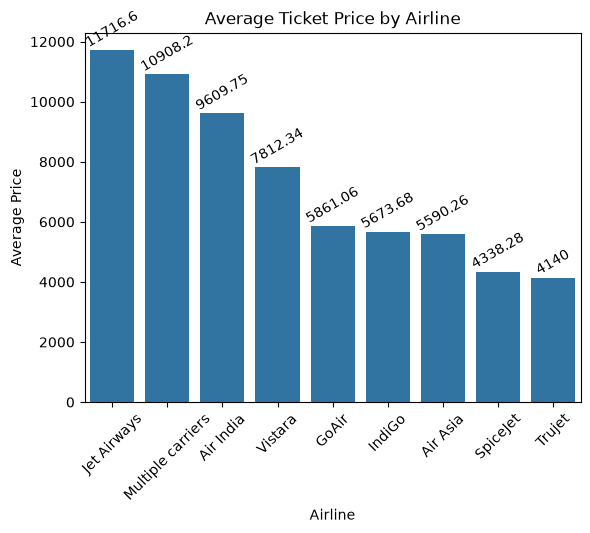

In [99]:
abc = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

ax = sns.barplot(x=abc.index, y=abc.values)

plt.title('Average Ticket Price by Airline')
plt.xlabel('Airline')
plt.bar_label(ax.containers[0],rotation=30)
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()


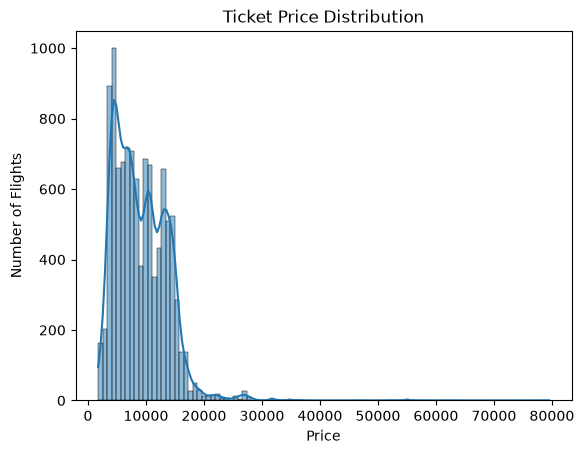

In [173]:
#6. Price Distribution — Histogram
sns.histplot(df['Price'], bins=100, kde=True)
plt.title('Ticket Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Flights')
plt.show()


In [222]:
Airines = df['Airline'].value_counts().sort_values(ascending=False).index
Airines


Index(['Jet Airways', 'IndiGo', 'Air India', 'Multiple carriers', 'SpiceJet',
       'Vistara', 'Air Asia', 'GoAir', 'Trujet'],
      dtype='str', name='Airline')

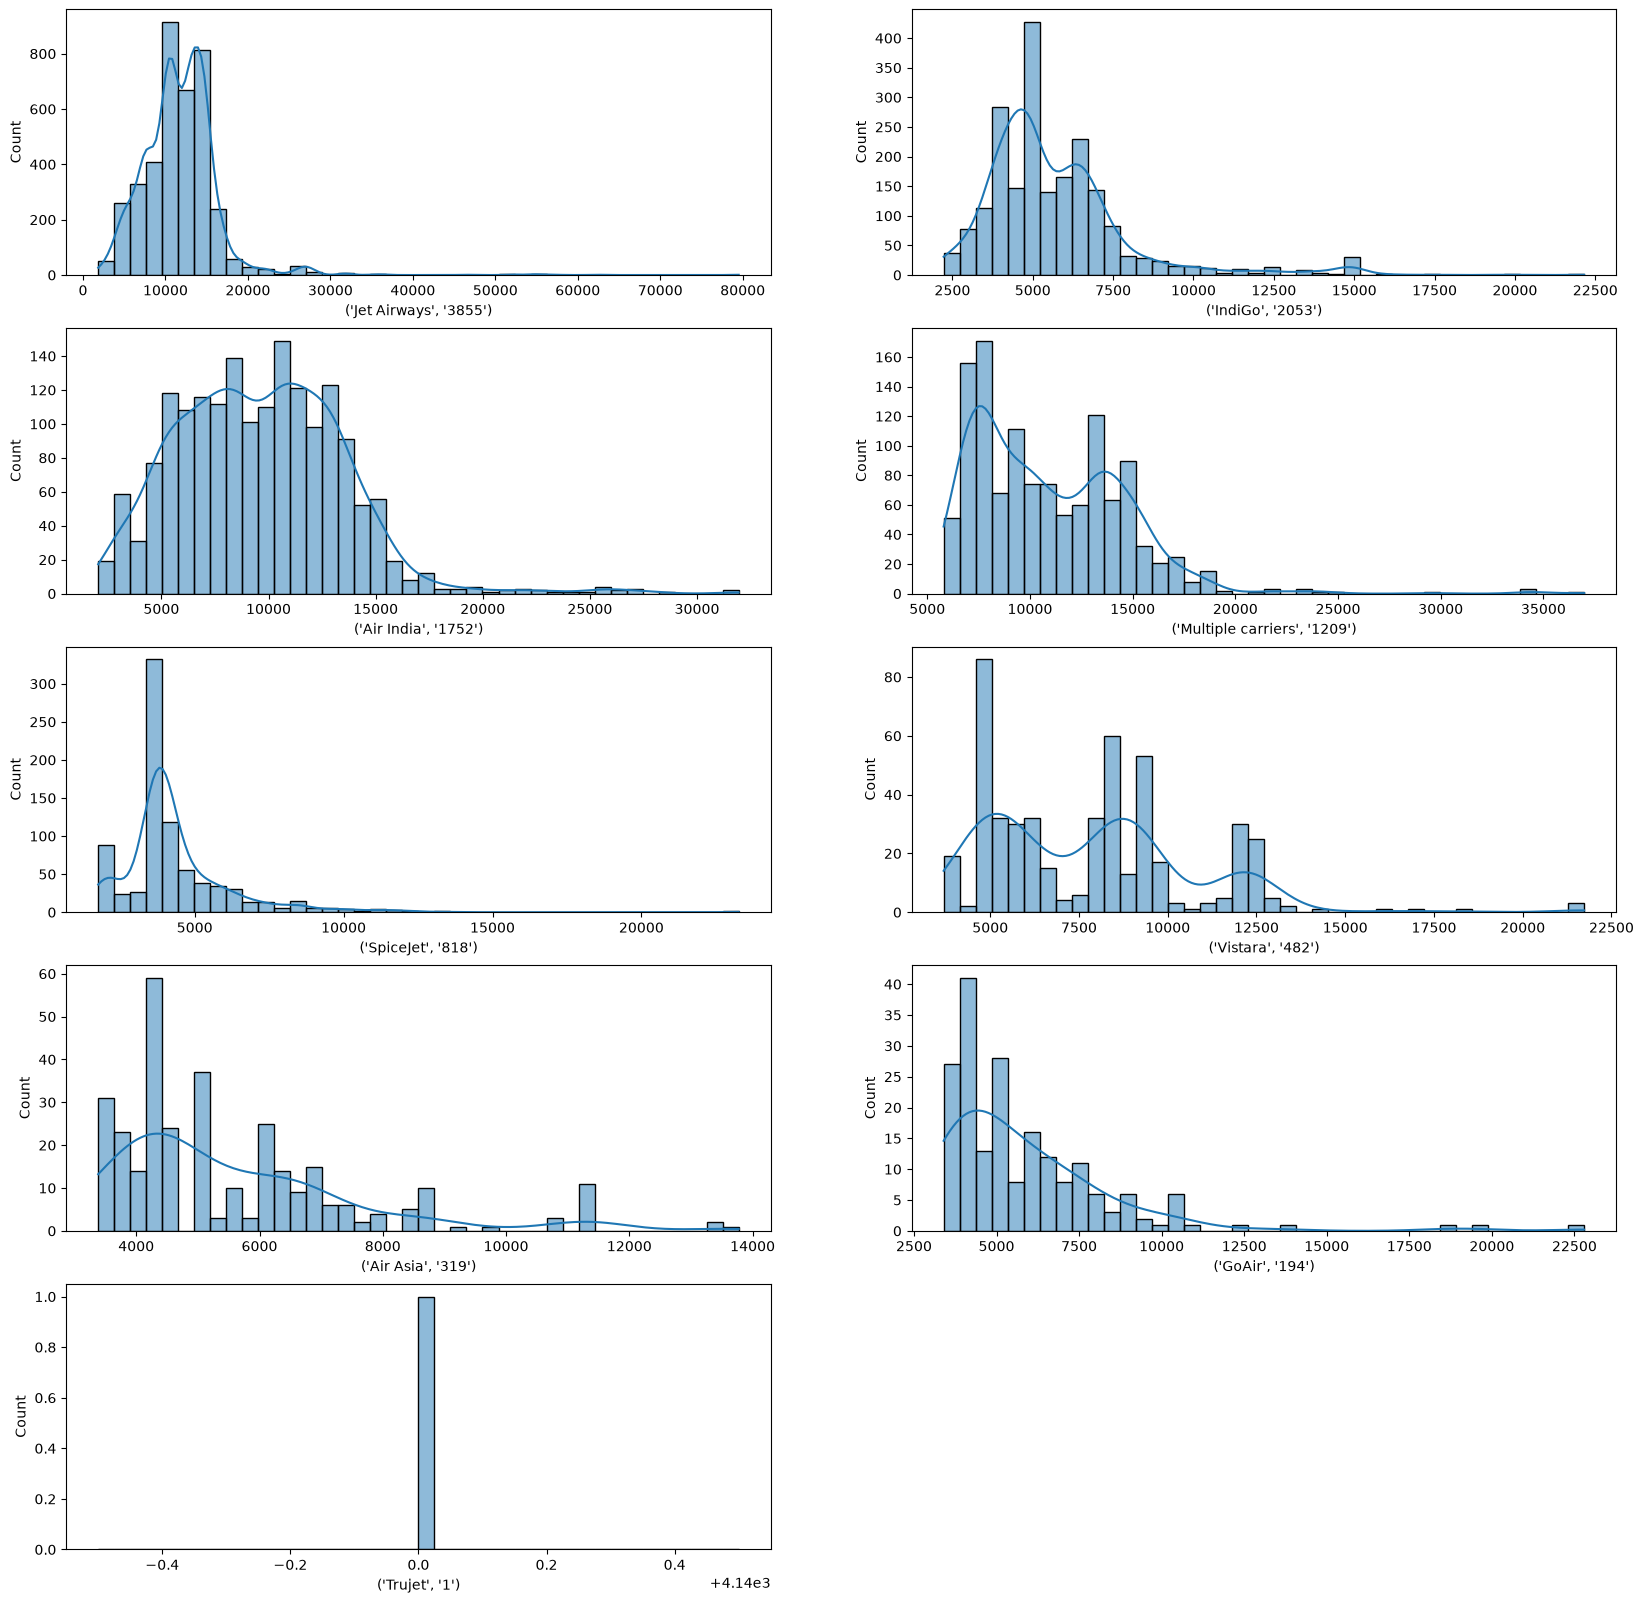

In [226]:

plt.figure(figsize=(20,20))
for k,v in enumerate(Airines):
    Air_Df = ""
    Air_Df = df[df['Airline']==v]
    pax_Count = Air_Df['Airline'].count()
    pax_Count = str(pax_Count)
    plt.subplot(5,2,k+1)
    sns.histplot(Air_Df['Price'],bins=40,kde=True)
    lavleV = v,pax_Count
    plt.xlabel(lavleV)

plt.show()


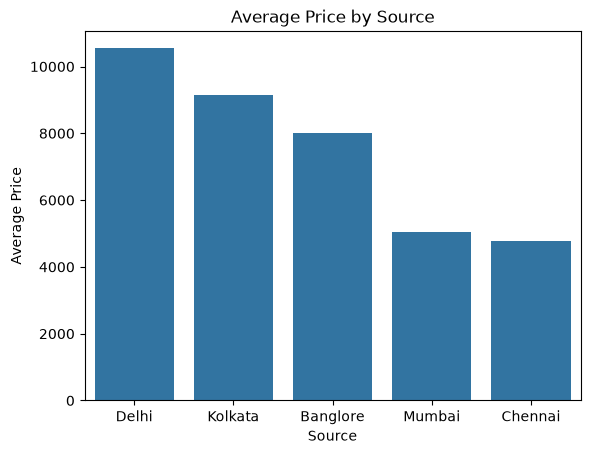

In [ ]:
abc = df.groupby('Source')['Price'].mean().sort_values(ascending=False)

sns.barplot(x=abc.index, y=abc.values)

plt.title('Average Price by Source')
plt.xlabel('Source')
plt.ylabel('Average Price')

plt.show()
l
